# POC — Wyckoff Trading-Range phase (arXiv:2403.18839v1, Listing 1)

Proof of concept for **Algorithm 1** of *Long Short-Term Memory Pattern Recognition in Currency
Trading* (Jai Pal, 2024) — the **Trading Range (TR)** phase geometry — run against real
**BTCUSDT** data instead of the paper's synthetic draws.

| | |
|---|---|
| Paper | [`research/paper/wyckoff/2403.18839_LSTM_Wyckoff_Currency_Trading.pdf`](../../research/paper/wyckoff/2403.18839_LSTM_Wyckoff_Currency_Trading.pdf) |
| Digest | [`research/wiki/wyckoff/…_digest.md`](../../research/wiki/wyckoff/2403.18839_LSTM_Wyckoff_Currency_Trading_digest.md) |
| Spec / write-up | [`01_trading_range_phase.md`](01_trading_range_phase.md) |
| Scope | Listing 1 only — the 4-point TR rule. Listing 2 (ST) and Listing 4 (LSTM) are **not** in this POC. |

**What this notebook answers:** the paper defines the TR phase as five inequalities over four
price points, but only ever evaluates that rule on data its own generator produced. What does
the same rule pick out on a real BTCUSDT chart, and does real price geometry land where the
generator's does?

**Three figures:**

1. `fig1_generator.png` — what Listing 1 actually draws (valid vs invalid).
2. `fig2_btcusdt_tr.png` — the rule applied to BTCUSDT 4h swings. **← the main output**
3. `fig3_shape_space.png` — real windows vs the generator's distribution, in the rule's own coordinates.

## 0 · Setup

Only `requests`, `pandas`, `numpy`, `matplotlib` are needed — **no TensorFlow**. This POC
implements the paper's *geometry*, not its classifier; the rule is five inequalities, so a
neural network is not required to evaluate it.

Colours follow the repo's data-viz palette: candles stay recessive grey (they are context),
and the swing chain / detected windows carry the only saturated hues (they are the story).

In [2]:
# !pip install requests pandas numpy matplotlib
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from matplotlib.patches import Polygon, Rectangle

# ----------------------------------------------------------------- config --
SYMBOL   = "BTCUSDT"
INTERVAL = "4h"
LIMIT    = 180      # ~30 days of 4h candles - deliberately narrow, this is a POC
PCT      = 0.015    # ZigZag reversal threshold (1.5%)
SEED     = 7

IMG = Path("images"); IMG.mkdir(exist_ok=True)
CACHE = Path("data"); CACHE.mkdir(exist_ok=True)

# ---------------------------------------------------------------- palette --
SURFACE, INK, INK_2, MUTED = "#fcfcfb", "#0b0b0b", "#52514e", "#898781"
GRID, AXIS = "#e1e0d9", "#c3c2b7"
S1_BLUE, S2_ORANGE, S3_AQUA = "#2a78d6", "#eb6834", "#1baf7a"
GOOD, CRITICAL = "#0ca30c", "#d03b3b"
HALO = dict(boxstyle="round,pad=0.15", fc=SURFACE, ec="none", alpha=0.85)

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.family": "sans-serif", "font.sans-serif": ["Segoe UI", "DejaVu Sans"],
    "text.color": INK, "axes.labelcolor": INK_2, "axes.edgecolor": AXIS,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "grid.color": GRID, "grid.linewidth": 0.8, "grid.linestyle": "-",
    "axes.grid": True, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 9,
    "figure.dpi": 110,
})
print("ready")

ready


## 1 · Listing 1, ported verbatim

Straight from p.5 of the PDF. Kept structurally identical to the paper — including the
`if not validity` branch's **accidental relabel**, where an unconstrained draw that happens to
satisfy the ordering gets its label flipped to `True`.

```python
def generate_pattern(validity):
    if validity:
        p1 = random.uniform(0, 100)
        p2 = random.uniform(0, p1)
        p3 = random.uniform(p2, p1)
        p4 = random.uniform(p2, p3)
        return [validity, p1, p2, p3, p4]
    if not validity:
        pattern = [validity, random.uniform(0,100), random.uniform(0,100),
                   random.uniform(0,100), random.uniform(0,100)]
        if pattern[1] > pattern[2] and pattern[2] < pattern[3] \
           and pattern[4] < pattern[3] and pattern[3] < pattern[1] \
           and pattern[4] > pattern[2]:
            pattern.remove(pattern[0]); pattern.insert(0, True)
        return pattern
```

### The rule, collapsed

The valid branch draws `p2 < p1`, then `p2 < p3 < p1`, then `p2 < p4 < p3`. Those five
inequalities are not independent — they collapse to a single chain:

$$p_2 \;<\; p_4 \;<\; p_3 \;<\; p_1$$

With the swings alternating **High, Low, High, Low**, that reads as: a **lower high**
($p_3 < p_1$) together with a **higher low** ($p_4 > p_2$) — i.e. a **contracting range**.

> ⚠️ **This contradicts the paper's own prose.** §2.1 says the TR phase forms *"lower lows and
> lower highs"*, but a lower low means $p_4 < p_2$, and Listing 1 requires the opposite. The code
> is what the LSTM was trained on, so the code is what this POC treats as the rule — `tr_rule_prose`
> below implements the prose version so the two can be compared on the same chart data.

In [3]:
def generate_pattern(validity, rng=random):
    """Verbatim port of Listing 1 (p.5, arXiv:2403.18839v1)."""
    if validity:
        p1 = rng.uniform(0, 100)
        p2 = rng.uniform(0, p1)
        p3 = rng.uniform(p2, p1)
        p4 = rng.uniform(p2, p3)
        return [validity, p1, p2, p3, p4]
    if not validity:
        pattern = [validity, rng.uniform(0, 100), rng.uniform(0, 100),
                   rng.uniform(0, 100), rng.uniform(0, 100)]
        if (pattern[1] > pattern[2] and pattern[2] < pattern[3]
                and pattern[4] < pattern[3] and pattern[3] < pattern[1]
                and pattern[4] > pattern[2]):
            pattern.remove(pattern[0])
            pattern.insert(0, True)   # <- the paper's accidental relabel
        return pattern


def tr_rule(p1, p2, p3, p4):
    """Listing 1's five inequalities == p2 < p4 < p3 < p1."""
    return (p1 > p2) and (p2 < p3) and (p4 < p3) and (p3 < p1) and (p4 > p2)


def tr_rule_prose(p1, p2, p3, p4):
    """What section 2.1's prose describes instead: lower high AND *lower low*."""
    return (p1 > p2) and (p3 < p1) and (p4 < p2)


# how often does the "invalid" branch silently relabel itself to True?
rng = random.Random(3)
N = 200_000
mis = sum(generate_pattern(False, rng)[0] is True for _ in range(N))
print(f"accidental relabel rate = {mis/N:.4%}   (theory: 1 of the 4! = 24 orderings = {1/24:.4%})")

accidental relabel rate = 4.1870%   (theory: 1 of the 4! = 24 orderings = 4.1667%)


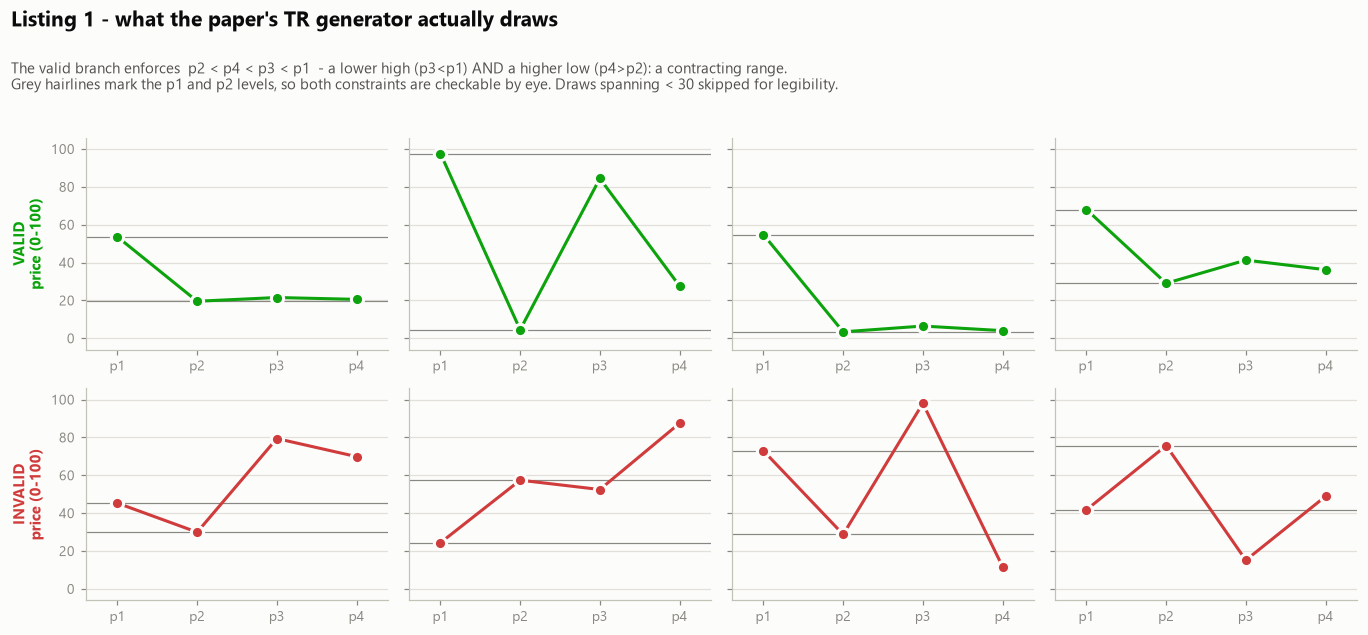

In [4]:
def fig_generator(seed=SEED, min_span=30):
    r = random.Random(seed)
    valids, invalids = [], []
    while len(valids) < 4:
        p = generate_pattern(True, r)
        if p[1] - p[2] >= min_span:
            valids.append(p)
    while len(invalids) < 4:
        p = generate_pattern(False, r)
        if p[0] is not True and max(p[1:]) - min(p[1:]) >= min_span:
            invalids.append(p)

    fig, axes = plt.subplots(2, 4, figsize=(12.5, 5.8), sharey=True)
    fig.suptitle("Listing 1 - what the paper's TR generator actually draws",
                 x=0.010, ha="left", fontsize=13.5, fontweight="bold", y=0.985)
    fig.text(0.010, 0.905,
             "The valid branch enforces  p2 < p4 < p3 < p1  - a lower high (p3<p1) AND a higher low (p4>p2): a contracting range.\n"
             "Grey hairlines mark the p1 and p2 levels, so both constraints are checkable by eye. Draws spanning < 30 skipped for legibility.",
             ha="left", fontsize=9.5, color=INK_2, va="top")

    for row, (batch, color, tag) in enumerate([(valids, GOOD, "VALID"), (invalids, CRITICAL, "INVALID")]):
        for col, pat in enumerate(batch):
            ax, pts = axes[row, col], pat[1:]
            ax.axhline(pts[0], color=MUTED, lw=0.8, zorder=1)
            ax.axhline(pts[1], color=MUTED, lw=0.8, zorder=1)
            ax.plot(range(1, 5), pts, "-", color=color, lw=2, zorder=3)
            ax.plot(range(1, 5), pts, "o", color=color, ms=8, mec=SURFACE, mew=2, zorder=4)
            ax.set_xlim(0.6, 4.4); ax.set_ylim(-6, 106)
            ax.set_xticks(range(1, 5)); ax.set_xticklabels([f"p{k}" for k in range(1, 5)])
            ax.grid(axis="x", visible=False)
            if col == 0:
                ax.set_ylabel(f"{tag}\nprice (0-100)", fontsize=10, color=color, fontweight="bold")
    fig.tight_layout(rect=[0, 0, 1, 0.865])
    fig.savefig(IMG / "fig1_generator.png", dpi=150)
    return fig

fig_generator();

## 2 · BTCUSDT data, and the step the paper leaves out

The paper never touches real market data — it generates `p1..p4` directly. To run the rule on a
chart, something has to **produce** those four points from OHLC bars, and the paper is silent on
how. That bridge is this POC's own addition, and it is the single biggest source of discretion
in the whole pipeline:

- **Swing detection** — a percentage-reversal **ZigZag**: confirm a swing high once price falls
  `PCT` from it, confirm a swing low once price rises `PCT` from it. Output alternates `H, L, H, L…`
- **Windowing** — slide a 4-swing window that starts on a **High**, so
  `(p1, p2, p3, p4) = (High, Low, High, Low)` — the shape Listing 1's ordering implies.
- **Scale** — the rule is pure ordering, so it is scale-invariant. No normalisation is needed to
  *evaluate* it; normalisation only matters in §4, for *comparing* shapes.

`PCT` is a free parameter the paper does not have, and the detection count is sensitive to it —
quantified in the sweep below.

In [5]:
def fetch_klines(symbol=SYMBOL, interval=INTERVAL, limit=LIMIT, use_cache=True):
    """Binance public spot klines. Cached to data/ so re-runs are reproducible."""
    f = CACHE / f"{symbol}_{interval}_{limit}.csv"
    if use_cache and f.exists():
        df = pd.read_csv(f, parse_dates=["open_time"])
        print(f"loaded cache {f}")
        return df
    r = requests.get("https://api.binance.com/api/v3/klines",
                     params={"symbol": symbol, "interval": interval, "limit": limit}, timeout=20)
    r.raise_for_status()
    cols = ["open_time", "open", "high", "low", "close", "volume", "close_time",
            "qav", "trades", "tbb", "tbq", "ignore"]
    df = pd.DataFrame(r.json(), columns=cols)
    df["open_time"] = pd.to_datetime(df["open_time"], unit="ms")
    for c in ["open", "high", "low", "close", "volume"]:
        df[c] = df[c].astype(float)
    df = df[["open_time", "open", "high", "low", "close", "volume"]].reset_index(drop=True)
    df.to_csv(f, index=False)
    print(f"fetched {len(df)} bars -> {f}")
    return df


def zigzag_swings(high, low, pct=PCT):
    """Percentage-reversal ZigZag -> strictly alternating (index, price, H|L) pivots.

    NOT from the paper - the bridge from OHLC bars to the p1..p4 the paper assumes.
    """
    high, low = np.asarray(high, float), np.asarray(low, float)
    piv = []
    hi_i, hi_p, lo_i, lo_p, trend = 0, high[0], 0, low[0], 0
    for i in range(1, len(high)):
        if high[i] > hi_p:
            hi_i, hi_p = i, high[i]
        if low[i] < lo_p:
            lo_i, lo_p = i, low[i]
        if trend >= 0 and low[i] <= hi_p * (1 - pct):        # drop pct from the high -> confirm H
            piv.append((hi_i, hi_p, "H")); trend = -1
            j = hi_i + int(np.argmin(low[hi_i:i + 1])); lo_i, lo_p = j, low[j]
        elif trend <= 0 and high[i] >= lo_p * (1 + pct):     # rise pct from the low -> confirm L
            piv.append((lo_i, lo_p, "L")); trend = 1
            j = lo_i + int(np.argmax(high[lo_i:i + 1])); hi_i, hi_p = j, high[j]
    return piv


def scan_tr(piv, rule=tr_rule):
    """Slide a 4-swing window starting on a High -> (p1,p2,p3,p4) = (H,L,H,L)."""
    out = []
    for s in range(len(piv) - 3):
        w = piv[s:s + 4]
        if [k for _, _, k in w] != ["H", "L", "H", "L"]:
            continue
        p1, p2, p3, p4 = [p for _, p, _ in w]
        out.append({"idx": [i for i, _, _ in w], "pts": [p1, p2, p3, p4],
                    "valid": bool(rule(p1, p2, p3, p4))})
    return out


def norm100(pts):
    lo, hi = min(pts), max(pts)
    return [0.0 if hi == lo else (p - lo) / (hi - lo) * 100 for p in pts]

In [6]:
df   = fetch_klines()
piv  = zigzag_swings(df["high"], df["low"], PCT)
wins = scan_tr(piv)
valid = [w for w in wins if w["valid"]]

print(f"{SYMBOL} {INTERVAL} | {len(df)} bars | {df.open_time.iloc[0]:%Y-%m-%d %H:%M} -> {df.open_time.iloc[-1]:%Y-%m-%d %H:%M}")
print(f"swings = {len(piv)}  ({''.join(k for _, _, k in piv)})")
print(f"H-led 4-swing windows = {len(wins)}   valid TR = {len(valid)}   hit rate = {len(valid)/max(len(wins),1):.1%}")
print()
for k, w in enumerate(valid, start=1):
    p1, p2, p3, p4 = w["pts"]
    t0 = df.open_time.iloc[w["idx"][0]]; t1 = df.open_time.iloc[w["idx"][3]]
    print(f"TR #{k}  {t0:%m-%d %H:%M} -> {t1:%m-%d %H:%M}   "
          f"p1={p1:,.0f}  p2={p2:,.0f}  p3={p3:,.0f}  p4={p4:,.0f}   "
          f"range={p1-p2:,.0f} ({(p1-p2)/p2:.2%})")

loaded cache data\BTCUSDT_4h_180.csv
BTCUSDT 4h | 180 bars | 2026-07-10 12:00 -> 2026-08-09 08:00
swings = 34  (HLHLHLHLHLHLHLHLHLHLHLHLHLHLHLHLHL)
H-led 4-swing windows = 16   valid TR = 3   hit rate = 18.8%

TR #1  07-16 12:00 -> 07-17 16:00   p1=64,896  p2=62,538  p3=64,388  p4=63,312   range=2,358 (3.77%)
TR #2  07-27 20:00 -> 07-29 04:00   p1=65,056  p2=62,742  p3=64,576  p4=63,598   range=2,314 (3.69%)
TR #3  07-31 12:00 -> 08-03 08:00   p1=63,849  p2=62,275  p3=63,796  p4=62,300   range=1,574 (2.53%)


In [7]:
# How much does the ZigZag threshold - the parameter the paper does not have - move the answer?
rows = []
for p in [0.008, 0.010, 0.015, 0.020, 0.030]:
    pv = zigzag_swings(df["high"], df["low"], p)
    w_code, w_prose = scan_tr(pv), scan_tr(pv, tr_rule_prose)
    rows.append({"zigzag_pct": f"{p:.1%}", "swings": len(pv), "windows": len(w_code),
                 "valid_listing1": sum(w["valid"] for w in w_code),
                 "valid_prose_lower_low": sum(w["valid"] for w in w_prose)})
pd.DataFrame(rows)

,zigzag_pct,swings,windows,valid_listing1,valid_prose_lower_low
0,0.8%,128,63,4,17
1,1.0%,94,46,1,14
2,1.5%,34,16,3,6
3,2.0%,24,11,3,2
4,3.0%,12,5,1,2


## 3 · The main output — Listing 1 applied to BTCUSDT

Grey candles are context. The blue chain is the ZigZag swing sequence the rule consumes. Every
aqua box is a 4-swing window that satisfies $p_2 < p_4 < p_3 < p_1$, drawn from $p_2$ (range
floor) to $p_1$ (range ceiling) — the trading range the paper's TR phase is describing.

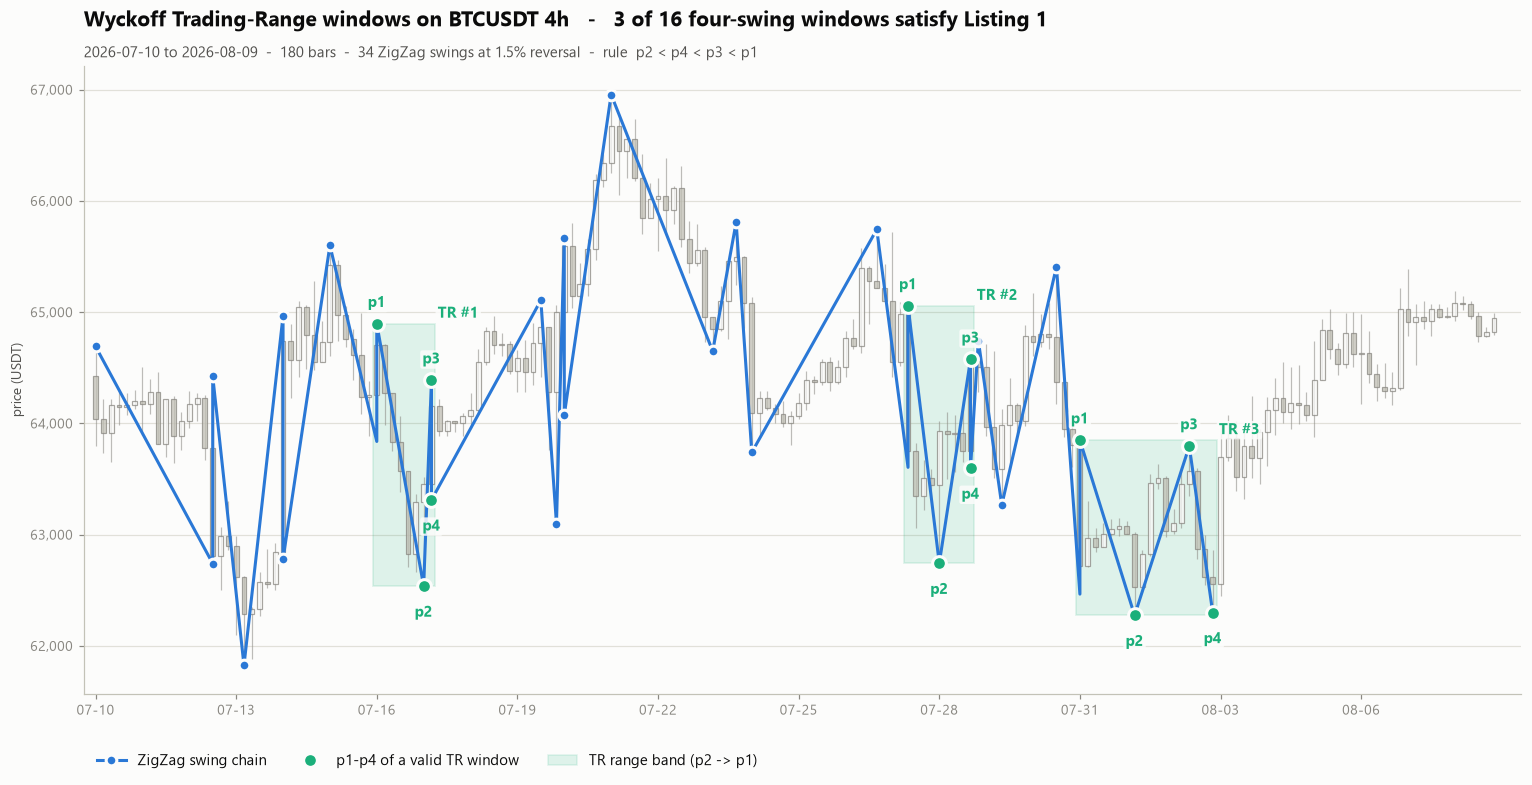

In [8]:
def fig_chart(df, piv, wins, symbol=SYMBOL, interval=INTERVAL, pct=PCT):
    n = len(df); x = np.arange(n)
    fig, ax = plt.subplots(figsize=(14, 7.2))

    up = df["close"] >= df["open"]
    ax.vlines(x, df["low"], df["high"], color=MUTED, lw=0.8, alpha=0.55, zorder=2)
    for mask, fc in [(up, SURFACE), (~up, AXIS)]:
        sub, xs = df[mask], x[mask.values]
        ax.bar(xs, (sub["close"] - sub["open"]).abs().clip(lower=1e-9),
               bottom=sub[["open", "close"]].min(axis=1), width=0.62,
               facecolor=fc, edgecolor=MUTED, linewidth=0.8, alpha=0.75, zorder=3)

    valid = [w for w in wins if w["valid"]]
    for k, w in enumerate(valid, start=1):
        i0, i3 = w["idx"][0], w["idx"][3]
        p1, p2 = w["pts"][0], w["pts"][1]
        ax.add_patch(Rectangle((i0 - 0.5, p2), (i3 - i0) + 1, p1 - p2, facecolor=S3_AQUA,
                               alpha=0.13, edgecolor=S3_AQUA, linewidth=1.2, zorder=1))
        ax.annotate(f"TR #{k}", (i3 + 0.8, p1), textcoords="offset points", xytext=(0, 4),
                    ha="left", fontsize=9.5, fontweight="bold", color=S3_AQUA, zorder=7, bbox=HALO)

    pi = [i for i, _, _ in piv]; pp = [p for _, p, _ in piv]
    ax.plot(pi, pp, "-", color=S1_BLUE, lw=2, zorder=4)
    used = {i for w in valid for i in w["idx"]}
    ax.plot([i for i in pi if i not in used], [p for i, p in zip(pi, pp) if i not in used],
            "o", color=S1_BLUE, ms=7, mec=SURFACE, mew=2, zorder=5)
    for w in valid:
        for lbl, i, p in zip(["p1", "p2", "p3", "p4"], w["idx"], w["pts"]):
            ax.plot(i, p, "o", color=S3_AQUA, ms=9, mec=SURFACE, mew=2, zorder=6)
            ax.annotate(lbl, (i, p), textcoords="offset points",
                        xytext=(0, 11 if lbl in ("p1", "p3") else -20), ha="center",
                        fontsize=9.5, fontweight="bold", color=S3_AQUA, zorder=7, bbox=HALO)

    t0, t1 = df["open_time"].iloc[0], df["open_time"].iloc[-1]
    ax.set_title(f"Wyckoff Trading-Range windows on {symbol} {interval}   -   "
                 f"{len(valid)} of {len(wins)} four-swing windows satisfy Listing 1",
                 loc="left", fontsize=13.5, fontweight="bold", pad=26)
    ax.annotate(f"{t0:%Y-%m-%d} to {t1:%Y-%m-%d}  -  {n} bars  -  {len(piv)} ZigZag swings at "
                f"{pct:.1%} reversal  -  rule  p2 < p4 < p3 < p1",
                xy=(0, 1.014), xycoords="axes fraction", fontsize=9.5, color=INK_2)
    ticks = list(range(0, n, max(1, n // 10)))
    ax.set_xticks(ticks); ax.set_xticklabels([f"{df['open_time'].iloc[i]:%m-%d}" for i in ticks])
    ax.set_ylabel("price (USDT)"); ax.set_xlim(-1.5, n + 2.5)
    ax.grid(axis="x", visible=False)
    ax.yaxis.set_major_formatter(lambda v, _: f"{v:,.0f}")
    h = [plt.Line2D([], [], color=S1_BLUE, lw=2, marker="o", ms=7, mec=SURFACE, mew=2),
         plt.Line2D([], [], color=S3_AQUA, lw=0, marker="o", ms=9, mec=SURFACE, mew=2),
         Rectangle((0, 0), 1, 1, facecolor=S3_AQUA, alpha=0.13, edgecolor=S3_AQUA)]
    ax.legend(h, ["ZigZag swing chain", "p1-p4 of a valid TR window", "TR range band (p2 -> p1)"],
              loc="upper left", frameon=False, fontsize=9.5, ncols=3, bbox_to_anchor=(0, -0.075))
    fig.tight_layout()
    fig.savefig(IMG / "fig2_btcusdt_tr.png", dpi=150)
    return fig

fig_chart(df, piv, wins);

## 4 · Where the real windows land in the rule's own coordinate system

Min–max normalise a **valid** window to 0–100 and $p_1$ becomes 100 and $p_2$ becomes 0 —
*by construction*, since the rule already declares $p_1$ the max and $p_2$ the min. So the entire
TR shape space is two-dimensional: the triangle $0 < p_4 < p_3 < 100$.

Plotting the synthetic cloud and the detected BTCUSDT windows in that plane shows two things at
once — how easy the classification problem is, and whether real price geometry occupies the same
part of the space the model was trained on.

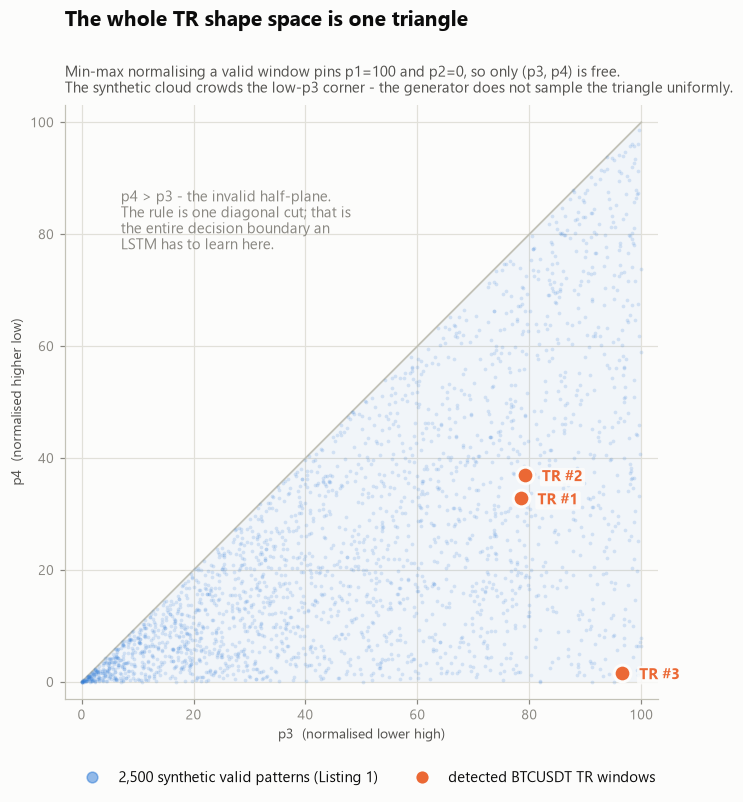

In [9]:
def fig_shape(wins, seed=11, n_syn=2500):
    r = random.Random(seed)
    syn = np.array([norm100(generate_pattern(True, r)[1:])[2:] for _ in range(n_syn)])

    fig, ax = plt.subplots(figsize=(7.8, 7.4))
    ax.add_patch(Polygon([(0, 0), (100, 0), (100, 100)], closed=True,
                         facecolor=S1_BLUE, alpha=0.05, edgecolor="none", zorder=1))
    ax.plot([0, 100], [0, 100], "-", color=AXIS, lw=1.2, zorder=2)
    ax.annotate("p4 > p3 - the invalid half-plane.\nThe rule is one diagonal cut; that is\n"
                "the entire decision boundary an\nLSTM has to learn here.",
                (7, 88), fontsize=9.5, color=MUTED, va="top", zorder=3)
    ax.scatter(syn[:, 0], syn[:, 1], s=6, color=S1_BLUE, alpha=0.16, linewidths=0, zorder=3)

    for k, w in enumerate([w for w in wins if w["valid"]], start=1):
        _, _, p3, p4 = norm100(w["pts"])
        ax.plot(p3, p4, "o", color=S2_ORANGE, ms=11, mec=SURFACE, mew=2, zorder=5)
        ax.annotate(f"TR #{k}", (p3, p4), textcoords="offset points", xytext=(11, -4),
                    fontsize=9.5, fontweight="bold", color=S2_ORANGE, zorder=5, bbox=HALO)

    ax.set_title("The whole TR shape space is one triangle",
                 loc="left", fontsize=13.5, fontweight="bold", pad=52)
    ax.annotate("Min-max normalising a valid window pins p1=100 and p2=0, so only (p3, p4) is free.\n"
                "The synthetic cloud crowds the low-p3 corner - the generator does not sample the triangle uniformly.",
                xy=(0, 1.015), xycoords="axes fraction", fontsize=9.5, color=INK_2, va="bottom")
    ax.set_xlabel("p3  (normalised lower high)"); ax.set_ylabel("p4  (normalised higher low)")
    ax.set_xlim(-3, 103); ax.set_ylim(-3, 103); ax.set_aspect("equal")
    ax.legend([plt.Line2D([], [], color=S1_BLUE, lw=0, marker="o", ms=7, alpha=0.5),
               plt.Line2D([], [], color=S2_ORANGE, lw=0, marker="o", ms=10, mec=SURFACE, mew=2)],
              [f"{n_syn:,} synthetic valid patterns (Listing 1)", "detected BTCUSDT TR windows"],
              loc="upper left", frameon=False, fontsize=9.5, bbox_to_anchor=(0, -0.10), ncols=2)
    fig.tight_layout()
    fig.savefig(IMG / "fig3_shape_space.png", dpi=150)
    return fig

fig_shape(wins);

## 5 · What this POC establishes

1. **Listing 1 encodes a contracting range, not the pattern §2.1 describes.** The code requires a
   lower high *and a higher low*; the prose says "lower lows and lower highs". The sweep in §2
   shows the two rules select materially different window counts from the same swing chain, so
   this is not a cosmetic discrepancy — the trained model learned the code's rule.

2. **The classification problem the paper reports 99.34% on is a single linear cut.** In the
   normalised coordinates of §4 the decision boundary is the line $p_4 = p_3$. That an LSTM
   separates it near-perfectly is a statement about the generator, not about markets.

3. **The paper's `invalid` branch is ~4.17% mislabelled** — 1 of the 4! = 24 orderings of four
   i.i.d. uniforms satisfies the rule, and the code relabels those to `True`. Measured in §1.

4. **The hard part is the step the paper skips.** Turning bars into `p1..p4` needs a swing
   detector the paper never specifies, and its threshold changes the detection count several-fold
   (§2 sweep). Any real deployment inherits that parameter as its dominant free variable.

5. **A detected "TR" is not yet a trade.** The rule has no notion of volume, of how long the range
   has held, or of where the range sits in a larger trend — all of which Wyckoff's own method
   treats as essential. Listing 1 is a shape filter, and should be used as one.

**Next**: Listing 2 (Secondary Test — equal lows) and Listing 4 (the LSTM itself). Neither is in
this notebook. See [`01_trading_range_phase.md`](01_trading_range_phase.md) § Next steps.